<a href="https://colab.research.google.com/github/abhiiyadav2595/Descriptive-Analytics/blob/main/Exp_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# STEP 1: Import Required Libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# For reproducible results
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# STEP 2: Generate Business Dataset

n = 120

data = {
    "Month_ID": range(1, n + 1),

    "Advertising_Spend": np.random.randint(1000, 10000, n),

    "Social_Media_Spend": np.random.randint(500, 5000, n),

    "Website_Visits": np.random.randint(1000, 20000, n),

    "Discount_Percentage": np.random.randint(5, 31, n),

    "Customer_Rating": np.round(
        np.random.uniform(3.0, 5.0, n), 2
    )
}

df = pd.DataFrame(data)

# Generate sales using multiple factors + some randomness
df["Sales_Units"] = (
    50
    + 0.035 * df["Advertising_Spend"]
    + 0.012 * df["Social_Media_Spend"]
    + 0.018 * df["Website_Visits"]
    + 3.5 * df["Discount_Percentage"]
    + np.random.normal(0, 80, n)
).round().astype(int)

# Prevent negative sales
df["Sales_Units"] = df["Sales_Units"].clip(lower=20)

# Revenue
df["Revenue"] = (
    df["Sales_Units"] *
    np.random.randint(400, 900, n)
)

df.head()

,Month_ID,Advertising_Spend,Social_Media_Spend,Website_Visits,Discount_Percentage,Customer_Rating,Sales_Units,Revenue
0,1,8270,4691,14992,13,4.14,846,431460
1,2,1860,2257,6699,16,4.15,180,119340
2,3,6390,2178,4987,25,4.46,488,401624
3,4,6191,3742,14446,5,3.26,672,516096
4,5,6734,1559,2218,30,3.50,425,269875


In [3]:
# STEP 3: Display Dataset Information

print("Number of observations:", len(df))
print("Number of variables:", len(df.columns))

display(df.head(10))

Number of observations: 120
Number of variables: 8


,Month_ID,Advertising_Spend,Social_Media_Spend,Website_Visits,Discount_Percentage,Customer_Rating,Sales_Units,Revenue
0,1,8270,4691,14992,13,4.14,846,431460
1,2,1860,2257,6699,16,4.15,180,119340
2,3,6390,2178,4987,25,4.46,488,401624
3,4,6191,3742,14446,5,3.26,672,516096
4,5,6734,1559,2218,30,3.50,425,269875
5,6,7265,2222,5735,30,4.16,446,214972
6,7,1466,3814,12296,5,4.73,377,166257
7,8,5426,3657,5555,19,4.12,572,471328
8,9,6578,3125,10146,6,3.48,472,236000
9,10,9322,3229,9050,26,4.36,784,317520


In [4]:
# STEP 4: Basic Dataset Inspection

print("Dataset Shape:")
print(df.shape)

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
display(df.describe())

Dataset Shape:
(120, 8)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Month_ID             120 non-null    int64  
 1   Advertising_Spend    120 non-null    int64  
 2   Social_Media_Spend   120 non-null    int64  
 3   Website_Visits       120 non-null    int64  
 4   Discount_Percentage  120 non-null    int64  
 5   Customer_Rating      120 non-null    float64
 6   Sales_Units          120 non-null    int64  
 7   Revenue              120 non-null    int64  
dtypes: float64(1), int64(7)
memory usage: 7.6 KB

Missing Values:
Month_ID               0
Advertising_Spend      0
Social_Media_Spend     0
Website_Visits         0
Discount_Percentage    0
Customer_Rating        0
Sales_Units            0
Revenue                0
dtype: int64

Statistical Summary:


,Month_ID,Advertising_Spend,Social_Media_Spend,Website_Visits,Discount_Percentage,Customer_Rating,Sales_Units,Revenue
count,120.000000,120.000000,120.0000,120.000000,120.000000,120.000000,120.000000,120.000000
mean,60.500000,5848.791667,2962.4000,10319.316667,17.566667,4.012417,540.700000,346262.141667
std,34.785054,2674.802850,1194.4288,5409.520242,8.339169,0.570160,162.560737,133935.397597
min,1.000000,1064.000000,598.0000,1190.000000,5.000000,3.060000,130.000000,70070.000000
25%,30.750000,3601.000000,2145.0000,5766.500000,9.000000,3.510000,428.000000,257145.000000
50%,60.500000,6267.000000,3091.0000,9513.500000,17.000000,3.980000,545.000000,340078.500000
75%,90.250000,8209.750000,3909.0000,15018.500000,25.000000,4.472500,632.250000,431798.750000
max,120.000000,9996.000000,4999.0000,19711.000000,30.000000,4.990000,994.000000,756918.000000


In [5]:
df.corr()

,Month_ID,Advertising_Spend,Social_Media_Spend,Website_Visits,Discount_Percentage,Customer_Rating,Sales_Units,Revenue
Month_ID,1.000000,0.093266,0.021456,0.027844,-0.044439,-0.146613,0.024008,-0.005081
Advertising_Spend,0.093266,1.000000,0.001250,-0.124078,0.053655,0.050284,0.551987,0.456825
Social_Media_Spend,0.021456,0.001250,1.000000,0.012577,0.084800,-0.095546,0.089283,-0.022429
Website_Visits,0.027844,-0.124078,0.012577,1.000000,0.000303,-0.175067,0.571813,0.452305
Discount_Percentage,-0.044439,0.053655,0.084800,0.000303,1.000000,0.113600,0.211794,0.197072
Customer_Rating,-0.146613,0.050284,-0.095546,-0.175067,0.113600,1.000000,-0.069336,-0.131318
Sales_Units,0.024008,0.551987,0.089283,0.571813,0.211794,-0.069336,1.000000,0.795704
Revenue,-0.005081,0.456825,-0.022429,0.452305,0.197072,-0.131318,0.795704,1.000000


In [6]:
# STEP 5: Pearson Correlation Matrix

correlation_matrix = df.corr(numeric_only=True)

print("Pearson Correlation Matrix:")
display(correlation_matrix.round(3))

Pearson Correlation Matrix:


,Month_ID,Advertising_Spend,Social_Media_Spend,Website_Visits,Discount_Percentage,Customer_Rating,Sales_Units,Revenue
Month_ID,1.000,0.093,0.021,0.028,-0.044,-0.147,0.024,-0.005
Advertising_Spend,0.093,1.000,0.001,-0.124,0.054,0.050,0.552,0.457
Social_Media_Spend,0.021,0.001,1.000,0.013,0.085,-0.096,0.089,-0.022
Website_Visits,0.028,-0.124,0.013,1.000,0.000,-0.175,0.572,0.452
Discount_Percentage,-0.044,0.054,0.085,0.000,1.000,0.114,0.212,0.197
Customer_Rating,-0.147,0.050,-0.096,-0.175,0.114,1.000,-0.069,-0.131
Sales_Units,0.024,0.552,0.089,0.572,0.212,-0.069,1.000,0.796
Revenue,-0.005,0.457,-0.022,0.452,0.197,-0.131,0.796,1.000


In [7]:
# STEP 6: Advertising Spend vs Sales Correlation

r_value = correlation_matrix.loc[
    "Advertising_Spend",
    "Sales_Units"
]

print(
    f"Pearson Correlation Coefficient (r): {r_value:.3f}"
)

Pearson Correlation Coefficient (r): 0.552


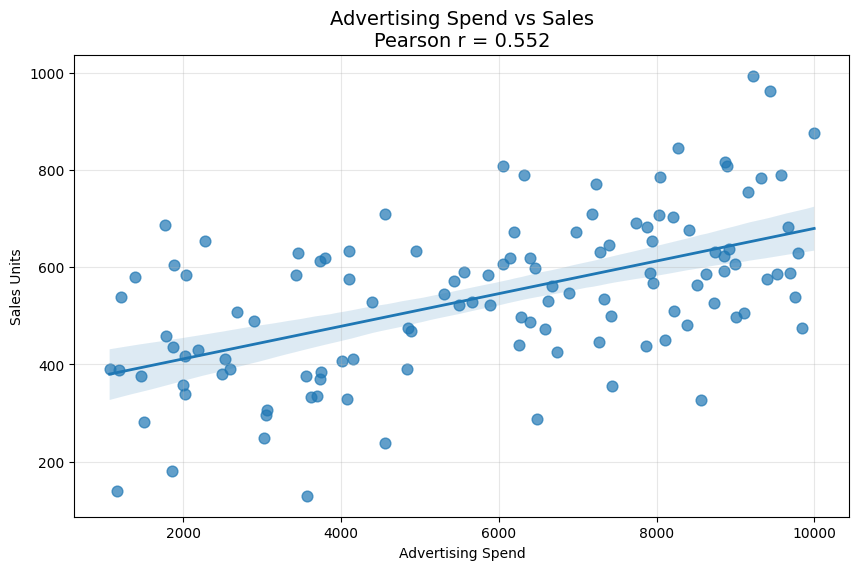

In [8]:
# STEP 7: Scatter Plot with Regression Line

plt.figure(figsize=(10, 6))

sns.regplot(
    x="Advertising_Spend",
    y="Sales_Units",
    data=df,
    scatter_kws={"s": 60, "alpha": 0.7},
    line_kws={"linewidth": 2}
)

plt.title(
    f"Advertising Spend vs Sales\nPearson r = {r_value:.3f}",
    fontsize=14
)

plt.xlabel("Advertising Spend")
plt.ylabel("Sales Units")

plt.grid(alpha=0.3)
plt.show()

In [9]:
# STEP 9: Find Strongest Correlations

corr_pairs = correlation_matrix.unstack()

corr_pairs = corr_pairs[
    corr_pairs != 1
]

corr_pairs = corr_pairs.sort_values(
    key=abs,
    ascending=False
)

print("Top 10 strongest relationships:")

display(
    corr_pairs.head(10).to_frame(
        name="Correlation"
    )
)

Top 10 strongest relationships:


Correlation
Revenue           Sales_Units           0.795704
Sales_Units       Revenue               0.795704
                  Website_Visits        0.571813
Website_Visits    Sales_Units           0.571813
Advertising_Spend Sales_Units           0.551987
Sales_Units       Advertising_Spend     0.551987
Revenue           Advertising_Spend     0.456825
Advertising_Spend Revenue               0.456825
Website_Visits    Revenue               0.452305
Revenue           Website_Visits        0.452305

In [11]:
# STEP 10: Automatic Interpretation

def interpret_correlation(r):

    strength = abs(r)

    if strength >= 0.9:
        level = "Very Strong"
    elif strength >= 0.7:
        level = "Strong"
    elif strength >= 0.5:
        level = "Moderate"
    elif strength >= 0.3:
        level = "Weak"
    else:
        level = "Very Weak"

    if r > 0:
        direction = "Positive"
    elif r < 0:
        direction = "Negative"
    else:
        direction = "No"

    return f"{level} {direction} correlation"


print("Advertising Spend vs Sales:")
print(interpret_correlation(r_value))

Advertising Spend vs Sales:
Moderate Positive correlation


In [12]:
# STEP 15: Demonstrating Negative Correlation

df["Profit_Margin"] = (
    35
    - 0.8 * df["Discount_Percentage"]
    + np.random.normal(0, 3, n)
)

negative_r = df[
    "Discount_Percentage"
].corr(
    df["Profit_Margin"]
)

print(
    f"Discount vs Profit Margin correlation: "
    f"{negative_r:.3f}"
)

Discount vs Profit Margin correlation: -0.916


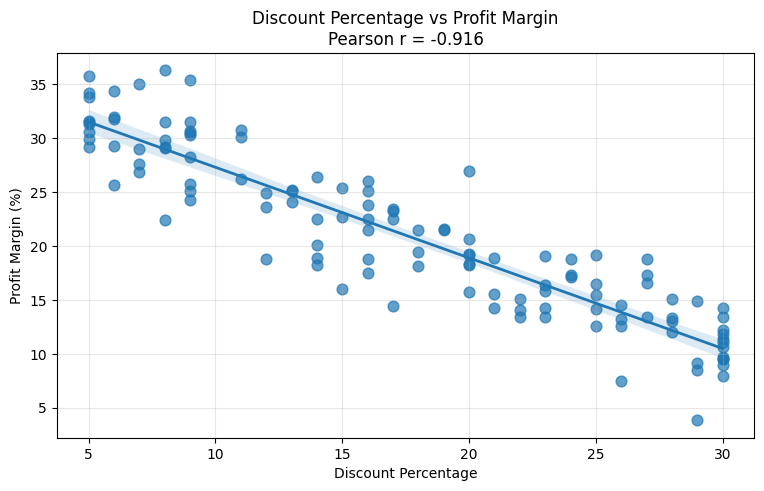

In [13]:
plt.figure(figsize=(9, 5))

sns.regplot(
    x="Discount_Percentage",
    y="Profit_Margin",
    data=df,
    scatter_kws={"s": 60, "alpha": 0.7},
    line_kws={"linewidth": 2}
)

plt.title(
    f"Discount Percentage vs Profit Margin\n"
    f"Pearson r = {negative_r:.3f}"
)

plt.xlabel("Discount Percentage")
plt.ylabel("Profit Margin (%)")

plt.grid(alpha=0.3)
plt.show()